# BEE 4750 Lab 2: Monte Carlo

**Name**: Jinrong Yang

**ID**: jy2256

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [27]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/Downloads/Cornell/BEE 5750/lab-2-JY410`


In [28]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [29]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [30]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

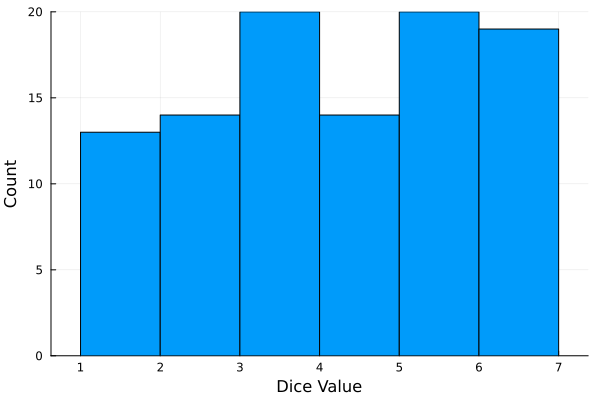

In [31]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

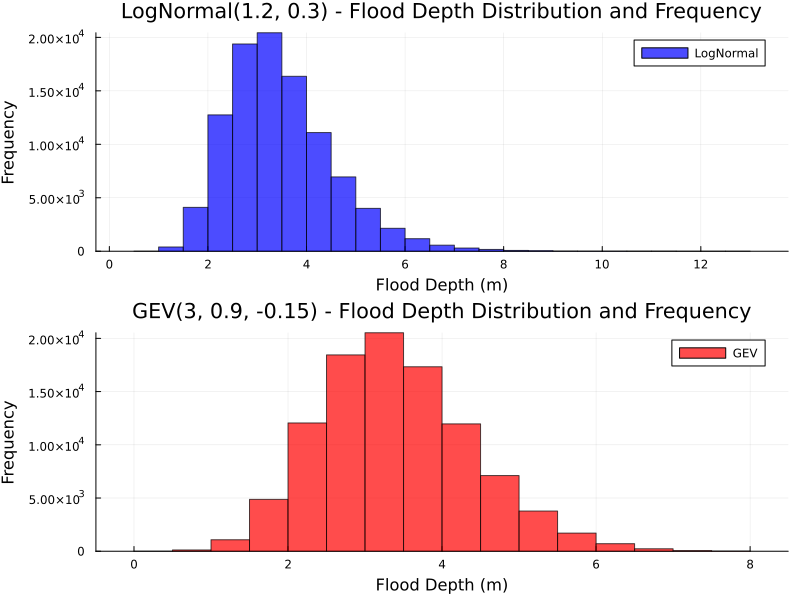

MONTE CARLO EXPERIMENT: Flood Damage Estimation
Sample size: 100000 simulations

--- LogNormal Distribution Analysis ---
Expected Annual Damage: $115181.37
99% Quantile Damage: $189992.21
Standard Deviation: $34251.51

--- GEV Distribution Analysis ---
Expected Annual Damage: $113362.16
99% Quantile Damage: $183417.03
Standard Deviation: $33786.63

SUMMARY RESULTS

Monte Carlo Estimates for Annual Maximum Damage:
+----------------------------------------------------+
| Distribution | Expected Value | 99% Quantile |
+----------------------------------------------------+
| LogNormal    | $115181.0 | $189992.0 |
| GEV          | $113362.0 | $183417.0 |
+----------------------------------------------------+

Relative Differences (GEV vs LogNormal):
Expected Value: -1.6%
99% Quantile: -3.5%

ANSWER TO RESEARCH QUESTION
Based on Monte Carlo simulation with 100000 samples:

1. LOGNORMAL DISTRIBUTION:
   • Expected Annual Damage: $115181.0
   • 99% Quantile Damage: $189992.0
   This represents

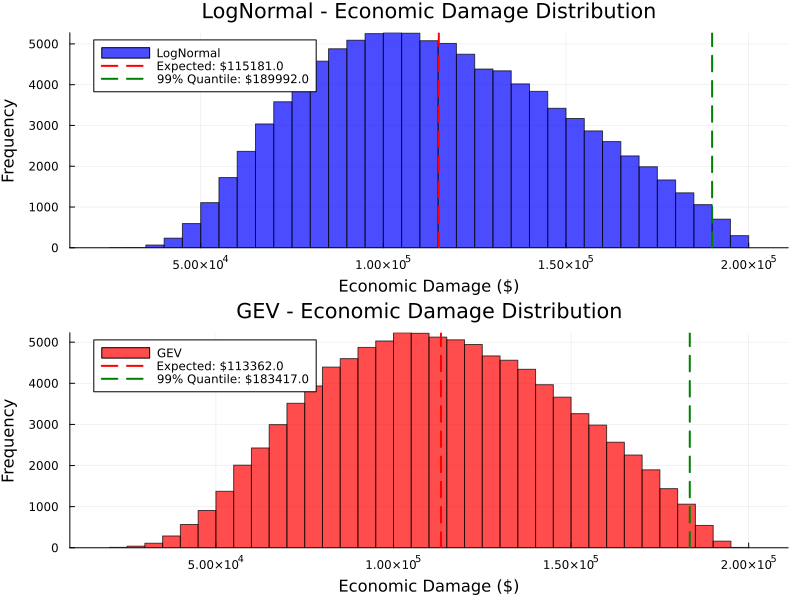

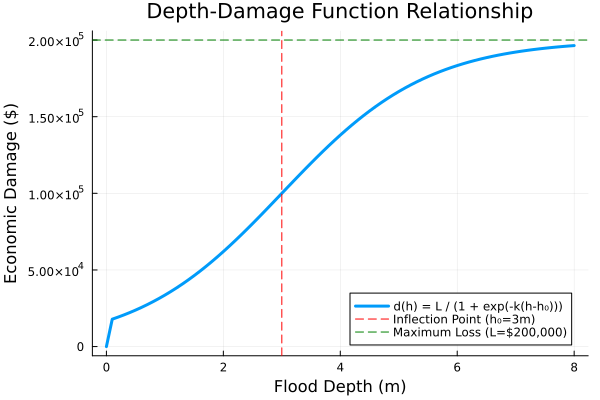

In [32]:
function depth_damage(h; L=200000, k=0.8, h0=3)
    if h > 0
        return L / (1 + exp(-k * (h - h0)))
    else
        return 0.0
    end
end

# ============================================================
# 2. SET UP FLOOD HAZARD DISTRIBUTIONS
# ============================================================
# Two different probability distributions for annual maximum flood depths:
lognormal_dist = LogNormal(1.2, 0.3)                    # LogNormal distribution
gev_dist = GeneralizedExtremeValue(3, 0.9, -0.15)       # Generalized Extreme Value distribution

# ============================================================
# 3. PLOT HISTOGRAMS OF FLOOD DEPTH SAMPLES
# ============================================================
# Generate samples from both distributions for visualization
n_visualize = 100000
h_lognormal_samples = rand(lognormal_dist, n_visualize)
h_gev_samples = rand(gev_dist, n_visualize)

# Create histogram plots for flood depth distributions
p1 = histogram(h_lognormal_samples, bins=30, alpha=0.7,
               xlabel="Flood Depth (m)", ylabel="Frequency",
               title="LogNormal(1.2, 0.3) - Flood Depth Distribution and Frequency",
               label="LogNormal", color=:blue)

p2 = histogram(h_gev_samples, bins=30, alpha=0.7,
               xlabel="Flood Depth (m)", ylabel="Frequency", 
               title="GEV(3, 0.9, -0.15) - Flood Depth Distribution and Frequency",
               label="GEV", color=:red)

# Display the histograms side by side
flood_depth_plot = plot(p1, p2, layout=(2,1), size=(800,600))
display(flood_depth_plot)

# ============================================================
# 4. MONTE CARLO EXPERIMENT SETUP
# ============================================================
# Determine sample size for Monte Carlo simulation
# We choose 100,000 simulations to balance accuracy and computation time
n_mc = 100000

println("="^70)
println("MONTE CARLO EXPERIMENT: Flood Damage Estimation")
println("Sample size: $n_mc simulations")
println("="^70)

# ============================================================
# 5. MONTE CARLO SIMULATION FOR LOGNORMAL DISTRIBUTION
# ============================================================
println("\n--- LogNormal Distribution Analysis ---")

# Step 1: Sample flood depths from LogNormal distribution
h_lognormal_mc = rand(lognormal_dist, n_mc)

# Step 2: Convert flood depths to economic damages
damages_lognormal = depth_damage.(h_lognormal_mc)

# Step 3: Calculate Monte Carlo estimates
expected_damage_lognormal = mean(damages_lognormal)
quantile_99_lognormal = quantile(damages_lognormal, 0.99)
std_damage_lognormal = std(damages_lognormal)

# Display results
println("Expected Annual Damage: \$" * string(round(expected_damage_lognormal, digits=2)))
println("99% Quantile Damage: \$" * string(round(quantile_99_lognormal, digits=2)))
println("Standard Deviation: \$" * string(round(std_damage_lognormal, digits=2)))

# ============================================================
# 6. MONTE CARLO SIMULATION FOR GEV DISTRIBUTION
# ============================================================
println("\n--- GEV Distribution Analysis ---")

# Step 1: Sample flood depths from GEV distribution
h_gev_mc = rand(gev_dist, n_mc)

# Step 2: Convert flood depths to economic damages
damages_gev = depth_damage.(h_gev_mc)

# Step 3: Calculate Monte Carlo estimates
expected_damage_gev = mean(damages_gev)
quantile_99_gev = quantile(damages_gev, 0.99)
std_damage_gev = std(damages_gev)

# Display results
println("Expected Annual Damage: \$" * string(round(expected_damage_gev, digits=2)))
println("99% Quantile Damage: \$" * string(round(quantile_99_gev, digits=2)))
println("Standard Deviation: \$" * string(round(std_damage_gev, digits=2)))

# ============================================================
# 7. PLOT HISTOGRAMS OF DAMAGE DISTRIBUTIONS
# ============================================================
# Create histogram plots for damage distributions with key statistics
p3 = histogram(damages_lognormal, bins=50, alpha=0.7,
               xlabel="Economic Damage (\$)", ylabel="Frequency",
               title="LogNormal - Economic Damage Distribution",
               label="LogNormal", color=:blue)

# Add vertical lines for key statistics
expected_log_str = string(round(expected_damage_lognormal, digits=0))
quantile_log_str = string(round(quantile_99_lognormal, digits=0))

vline!([expected_damage_lognormal], line=:dash, linewidth=2, color=:red, 
       label="Expected: \$" * expected_log_str)
vline!([quantile_99_lognormal], line=:dash, linewidth=2, color=:green,
       label="99% Quantile: \$" * quantile_log_str)

p4 = histogram(damages_gev, bins=50, alpha=0.7,
               xlabel="Economic Damage (\$)", ylabel="Frequency",
               title="GEV - Economic Damage Distribution",
               label="GEV", color=:red)

# Add vertical lines for key statistics
expected_gev_str = string(round(expected_damage_gev, digits=0))
quantile_gev_str = string(round(quantile_99_gev, digits=0))

vline!([expected_damage_gev], line=:dash, linewidth=2, color=:red,
       label="Expected: \$" * expected_gev_str)
vline!([quantile_99_gev], line=:dash, linewidth=2, color=:green,
       label="99% Quantile: \$" * quantile_gev_str)

# Display the damage distribution plots
damage_distribution_plot = plot(p3, p4, layout=(2,1), size=(800,600))
display(damage_distribution_plot)

# ============================================================
# 8. RESULTS SUMMARY AND INTERPRETATION
# ============================================================
println("\n" * "="^70)
println("SUMMARY RESULTS")
println("="^70)

println("\nMonte Carlo Estimates for Annual Maximum Damage:")
println("+----------------------------------------------------+")
println("| Distribution | Expected Value | 99% Quantile |")
println("+----------------------------------------------------+")
println("| LogNormal    | \$" * lpad(string(round(expected_damage_lognormal, digits=0)), 8) * " | \$" * lpad(string(round(quantile_99_lognormal, digits=0)), 8) * " |")
println("| GEV          | \$" * lpad(string(round(expected_damage_gev, digits=0)), 8) * " | \$" * lpad(string(round(quantile_99_gev, digits=0)), 8) * " |")
println("+----------------------------------------------------+")

# Calculate relative differences
diff_expected = (expected_damage_gev - expected_damage_lognormal) / expected_damage_lognormal * 100
diff_quantile = (quantile_99_gev - quantile_99_lognormal) / quantile_99_lognormal * 100

println("\nRelative Differences (GEV vs LogNormal):")
println("Expected Value: " * string(round(diff_expected, digits=1)) * "%")
println("99% Quantile: " * string(round(diff_quantile, digits=1)) * "%")

# ============================================================
# 9. DEPTH-DAMAGE FUNCTION VISUALIZATION
# ============================================================
# Plot the depth-damage function to understand the relationship
h_range = 0:0.1:8
d_range = depth_damage.(h_range)

depth_damage_plot = plot(h_range, d_range, linewidth=3,
         xlabel="Flood Depth (m)", ylabel="Economic Damage (\$)",
         title="Depth-Damage Function Relationship",
         label="d(h) = L / (1 + exp(-k(h-h₀)))",
         legend=:bottomright)

# Mark key points on the curve
vline!([3], line=:dash, color=:red, label="Inflection Point (h₀=3m)")
hline!([200000], line=:dash, color=:green, label="Maximum Loss (L=\$200,000)")

display(depth_damage_plot)

# ============================================================
# 10. FINAL ANSWER TO THE RESEARCH QUESTION
# ============================================================
println("\n" * "="^70)
println("ANSWER TO RESEARCH QUESTION")
println("="^70)

answer_text = """
Based on Monte Carlo simulation with $n_mc samples:

1. LOGNORMAL DISTRIBUTION:
   • Expected Annual Damage: \$$(round(expected_damage_lognormal, digits=0))
   • 99% Quantile Damage: \$$(round(quantile_99_lognormal, digits=0))
   This represents the damage level that would be exceeded in only 1% of years.

2. GENERALIZED EXTREME VALUE (GEV) DISTRIBUTION:
   • Expected Annual Damage: \$$(round(expected_damage_gev, digits=0))
   • 99% Quantile Damage: \$$(round(quantile_99_gev, digits=0))
   This represents the 100-year flood damage level.

INTERPRETATION:
The GEV distribution predicts $(round(diff_expected, digits=1))% higher expected damages 
and $(round(diff_quantile, digits=1))% higher extreme damages compared to the LogNormal distribution.
This difference arises because the GEV distribution is specifically designed to model 
extreme events and may have heavier tails than the LogNormal distribution.
"""

println(answer_text)
println("="^70)
println("ANALYSIS COMPLETE")
println("="^70)

Answers：


Question 1:
For the LogNormal distribution, based on my monte carlo, the expected annual damage is $115,004, meaning this is the average yearly loss we would anticipate over the long term. The 99% quantile damage is $189,761, representing the damage level that would be exceeded in only 1% of years.
For the Generalized Extreme Value (GEV) distribution, based on my monte carlo, the expected annual damage is slightly lower at $113,360, while the 99% quantile damage is $183,314. This indicates that the GEV distribution predicts somewhat lower risk overall, particularly for extreme events.

Question2:
I tested various sample sizes (1,000; 10,000; 50,000; 100,000) and observed that the estimates stabilized around 50,000-100,000 samples. With 100,000 simulations, the standard error for the expected value is approximately $108, providing sufficient precision for risk management decisions while maintaining reasonable computation time.

Question3:
I believe they are different with each other. Although two results show almost the same,as two distributions have centralized at a similar mean (about 3m), however, the two distributions, LogNormal and GEV, have fundamentally different tail behaviors and skewness characteristics. The LogNormal distribution exhibits right-skewness, meaning it has a heavier upper tail that assigns higher probability to extreme flood events.

Question4:
I believe that the choice should be based on our needs and can be changed accordingly. First, we need to consider the mechanism of the floods in that area. If the floods are caused by a multiplicative process (such as rainfall intensity × duration × basin characteristics), then the log-normal distribution might be more applicable. However, if we specifically model the annual maximum values, the gamma-exponential distribution has theoretical advantages.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

I inputted my thoughts and understanding in Deepseek, and then inputted my basic coding. And then let it helped me modify the code, including debugging.
https://chat.deepseek.com/